## Introduction 

In this script, the global closeness per ward is computed. 

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [5]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml_drive.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [6]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [7]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [8]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 369 wards in the dataset.


Reading in the entire Bangalore network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [10]:
G = ox.io.load_graphml(path_graphml)

In [11]:
G.graph["crs"]

'epsg:4326'

In [12]:
df.crs.to_epsg()

4326

## Computing (global) closeness at the ward level

In [15]:
results = pd.DataFrame(columns=['ward_id', 'ward_name', 'Corporatio', 'closeness'])
results

,ward_id,ward_name,Corporatio,closeness


In [16]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    id_ward = df['ward_id'].iloc[ward]
    name_ward = df['ward_name'].iloc[ward]
    corporation = df['Corporatio'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.closeness_centrality(primal, name='closeness_global', weight='mm_len')

    nodes = momepy.nx_to_gdf(primal, lines=False)

    closeness_mean = nodes['closeness_global'].mean()

    results.loc[ward] = [
        id_ward,
        name_ward,
        corporation,
        closeness_mean
    ]
    

Processing wards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 369/369 [46:54<00:00,  7.63s/it]


In [17]:
results

,ward_id,ward_name,Corporatio,closeness
0,25,25 - Vinayaka Layout,West,0.000795
1,2,2 - Aerocity,North,0.000428
2,3,3 - Chowdeshwari ward,North,0.000434
3,15,15 - Ramamurthy Nagara,East,0.001345
4,58,58 - Nagashettyhalli,North,0.001439
...,...,...,...,...
364,56,56 - Gopalpura,Central,0.000995
365,57,57 - Cottonpete,Central,0.001889
366,54,54 - Binnypete,Central,0.001203
367,47,47 - IPD Salappa Ward,Central,0.001320


In [18]:
top10_highest = (
    results
    .sort_values(by='closeness', ascending=False)
    .head(10)
)
top10_highest

,ward_id,ward_name,Corporatio,closeness
274,39,39 - Venkat Reddy Nagara,Central,0.003057
184,88,88 - Sangolli Rayanna Ward,West,0.002891
258,46,46 - Cheluvadi Palya,Central,0.002858
117,25,25 - National Games Village,South,0.002855
26,51,51 - Old Guddadahalli,Central,0.002849
42,3,3 - Yarab nagar,South,0.002802
233,28,28 - Neelasandra,Central,0.002759
159,65,65 - Manjunath Nagara,West,0.002706
271,6,6 - Bharathi Nagar,Central,0.002678
235,55,55 - Bhuvaneshwari Nagar,Central,0.002634


In [19]:
top10_lowest = (
    results
    .sort_values(by='closeness', ascending=True)
    .head(10)
)
top10_lowest

,ward_id,ward_name,Corporatio,closeness
238,50,50 - Gunjur,East,0.000226
18,20,20 - Kengeri Kote ward,West,0.000267
71,37,37 - Yelenahalli,South,0.000273
91,6,6 - Doddabettahalli,North,0.000274
138,15,15 - Byatarayanapura,North,0.000277
74,28,28 - Byrathi,East,0.000285
236,38,38 - Whitefield,East,0.000287
130,31,31 - Kasavanahalli,South,0.000304
5,21,21 - Kogilu,North,0.000310
34,2,2 - Horamavu,East,0.000313


In [20]:
print(f'The mean of the global closeness across the wards is {results["closeness"].mean()}.')
print(f'The minimum of the global closeness across the wards is {results["closeness"].min()}.')
print(f'The maximum of the global closeness across the wards is {results["closeness"].max()}.')

The mean of the global closeness across the wards is 0.001140404247286949.
The minimum of the global closeness across the wards is 0.00022615283883904786.
The maximum of the global closeness across the wards is 0.0030569713286973826.


In [21]:
## Save this:
results_path = PROCESSED_DIR / "results_bangalore_global_closeness_all_roads_drive.csv"

results.to_csv(results_path)

In [22]:
# You can normally do things from results but I had to read them in later
results_path = PROCESSED_DIR / "results_bangalore_global_closeness_all_roads_drive.csv"
results = pd.read_csv(results_path)

In [23]:
results = pd.read_csv(results_path)
results

,Unnamed: 0,ward_id,ward_name,Corporatio,closeness
0,0,25,25 - Vinayaka Layout,West,0.000795
1,1,2,2 - Aerocity,North,0.000428
2,2,3,3 - Chowdeshwari ward,North,0.000434
3,3,15,15 - Ramamurthy Nagara,East,0.001345
4,4,58,58 - Nagashettyhalli,North,0.001439
...,...,...,...,...,...
364,364,56,56 - Gopalpura,Central,0.000995
365,365,57,57 - Cottonpete,Central,0.001889
366,366,54,54 - Binnypete,Central,0.001203
367,367,47,47 - IPD Salappa Ward,Central,0.001320


In [24]:
df_merged = df.merge(results, on = 'ward_name')
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,Unnamed: 0,ward_id_y,Corporatio_y,closeness
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0,25,West,0.000795
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",1,2,North,0.000428
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",2,3,North,0.000434
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",3,15,East,0.001345
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",4,58,North,0.001439
...,...,...,...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",364,56,Central,0.000995
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",365,57,Central,0.001889
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",366,54,Central,0.001203
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",367,47,Central,0.001320


In [25]:
df_merged = df_merged[['ward_id_x', 'ward_name', 'Corporatio_x', 'geometry', 'closeness']]
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,closeness
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0.000795
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",0.000428
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",0.000434
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",0.001345
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",0.001439
...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",0.000995
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",0.001889
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",0.001203
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",0.001320


In [26]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio_x': 'Corporatio'
})

## Plots

The ward with the highest straightness

In [27]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'closeness_global_all_roads_bangalore_drive.png'

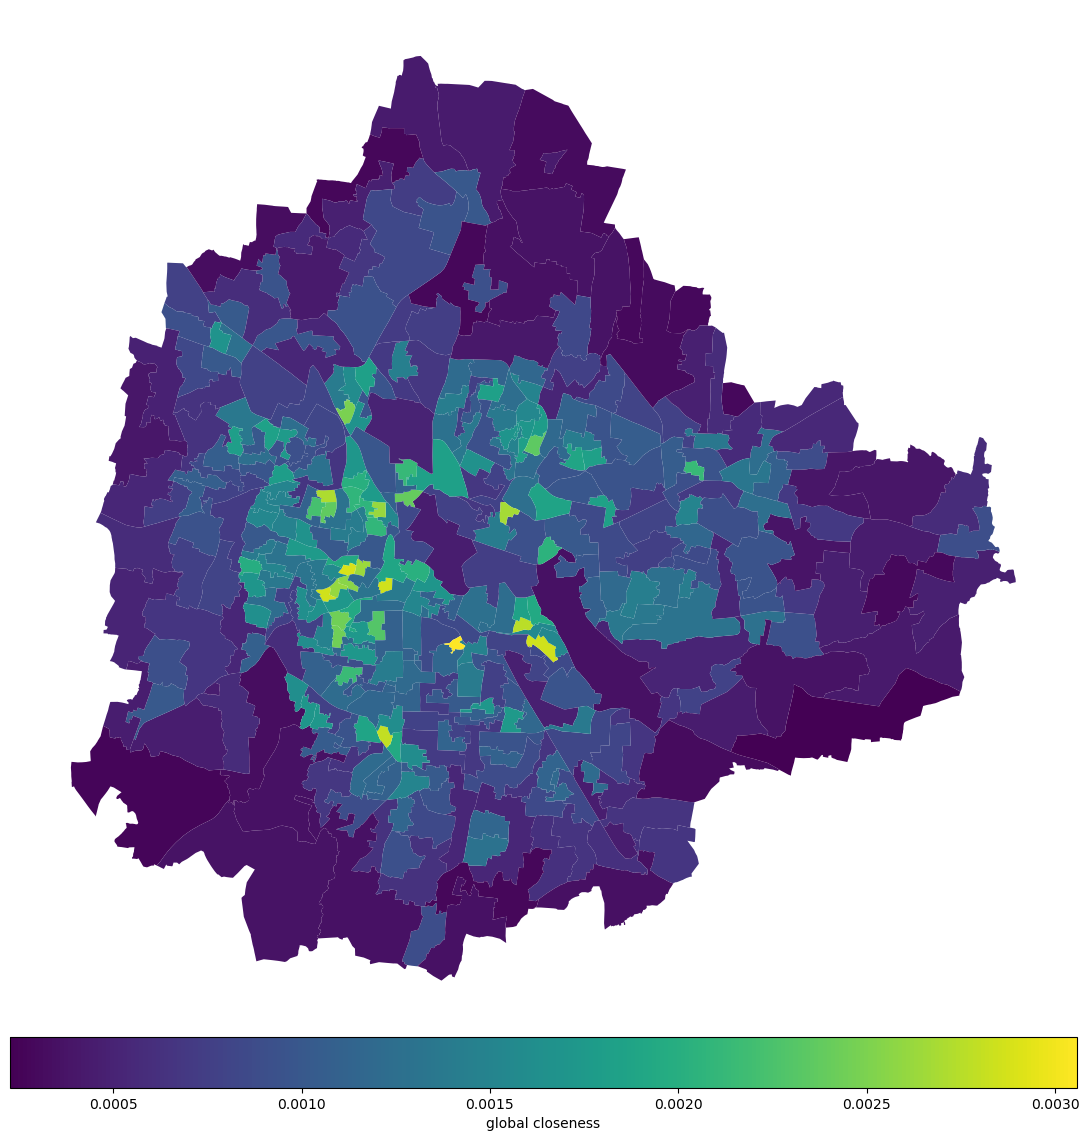

In [28]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="closeness",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "global closeness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()